### Implementing simple Chatbot Using LangGraph

In [33]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages



In [34]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [35]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [36]:
from langchain_groq import ChatGroq

llm_groq=ChatGroq(model="qwen/qwen3-32b")
llm_groq.invoke("Hey I am Harsh and i like to play cricket")

AIMessage(content="<think>\nOkay, the user introduced himself as Harsh and mentioned he likes to play cricket. Let me think about how to respond appropriately.\n\nFirst, I should acknowledge his introduction and express enthusiasm about his interest in cricket. It's important to be friendly and encouraging.\n\nI can ask him about his role in the game, like whether he's a batsman, bowler, or all-rounder. That shows interest in his specific involvement with the sport.\n\nMaybe also ask about his favorite teams or players. That could lead to a deeper conversation about the game and shared interests.\n\nI should keep the tone positive and open-ended to invite him to share more. Also, make sure to use emojis to keep it light and approachable.\n\nCheck if there's a need to offer any information about cricket, like tips or current events, but only if he asks. Otherwise, just keep the conversation flowing naturally.\n\nAvoid making assumptions beyond what he's said. Don't mention specific team

In [30]:
def superbot(state:State):
    return {"messages":[llm_groq.invoke(state['messages'])]}

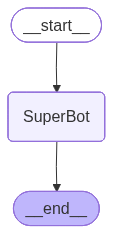

In [31]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile()


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [32]:
graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket"})

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='bacd16d1-c0bb-4522-989f-058313c49d42'),
  AIMessage(content="<think>\nOkay, the user is Krish and he mentioned he likes cricket. Let me start by acknowledging his introduction and express interest in his favorite sport. I should ask him about his specific interests within cricket. Maybe he's a fan of a particular team or player. I should also invite him to share more about his experiences with cricket, like if he plays it or just watches. Keeping the tone friendly and open-ended will encourage him to elaborate. Let me make sure to ask a question that can lead to further conversation. I need to check if there's anything else relevant to add, but since he only mentioned his name and interest in cricket, focusing on that should be enough. I should avoid any assumptions and let him guide the conversation.\n</think>\n\nHi Krish! Great to meet you. Cricket is an amazin